<a href="https://colab.research.google.com/github/Shravanya178/MLDL_EXPS/blob/main/MLDL_EXP6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
df = pd.read_csv("CEEW - IRES Data.csv", low_memory=False)
print("Dataset shape:", df.shape)

Dataset shape: (14851, 517)


In [3]:
fields = [
    'avg_monthly_bill',
    'q302_grid_hrs_no',
    'q308_grid_voltage_low_app',
    'q405_c_led_bulb_no',
    'q410_ceiling_fan_no',
    'q467_fridge_no',
    'q460_tv_no',
    'q232_mobile_smart_n'
]

df_cluster = df[fields].dropna()

print("Clustering dataset shape:", df_cluster.shape)
df_cluster.describe()

Clustering dataset shape: (2987, 8)


,avg_monthly_bill,q302_grid_hrs_no,q308_grid_voltage_low_app,q405_c_led_bulb_no,q410_ceiling_fan_no,q467_fridge_no,q460_tv_no,q232_mobile_smart_n
count,2987.000000,2987.000000,2987.000000,2987.000000,2987.000000,2987.000000,2987.000000,2987.000000
mean,1016.676152,22.180449,0.503180,3.155340,2.273853,1.014061,1.046870,1.898895
std,884.715837,3.174419,1.449845,2.281432,1.111347,0.120572,0.219173,1.143060
min,0.000000,7.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,400.000000,22.000000,0.000000,2.000000,1.000000,1.000000,1.000000,1.000000
50%,796.666690,24.000000,0.000000,3.000000,2.000000,1.000000,1.000000,2.000000
75%,1400.000000,24.000000,0.000000,4.000000,3.000000,1.000000,1.000000,2.000000
max,8333.333000,24.000000,15.000000,20.000000,8.000000,3.000000,4.000000,8.000000


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

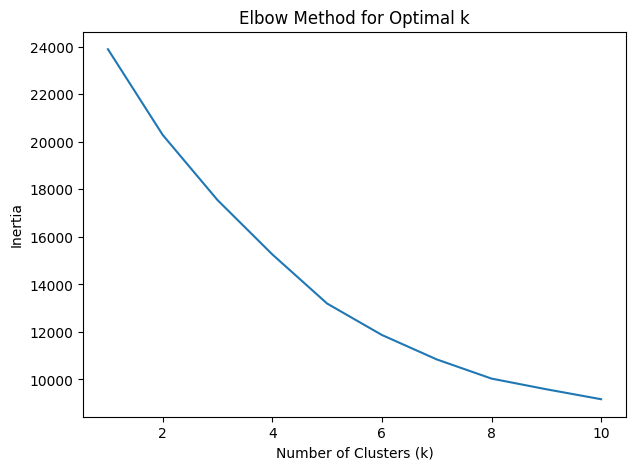

In [5]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1, 11), inertia)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [6]:
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 2, Silhouette Score = 0.5586
k = 3, Silhouette Score = 0.3035
k = 4, Silhouette Score = 0.3111
k = 5, Silhouette Score = 0.2572
k = 6, Silhouette Score = 0.2679


In [7]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_cluster['Cluster'] = clusters

df_cluster['Cluster'].value_counts()

,count
Cluster,
0,2200
2,746
1,41


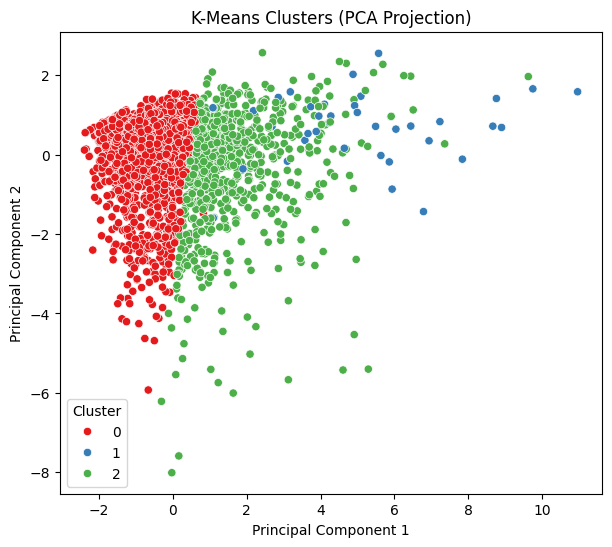

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='Set1')
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [9]:
cluster_profile = df_cluster.groupby('Cluster').mean()
cluster_profile

,avg_monthly_bill,q302_grid_hrs_no,q308_grid_voltage_low_app,q405_c_led_bulb_no,q410_ceiling_fan_no,q467_fridge_no,q460_tv_no,q232_mobile_smart_n
Cluster,,,,,,,,
0,813.885000,22.347273,0.374091,2.476818,1.847727,1.00000,1.002727,1.625909
1,1414.308958,23.000000,0.609756,5.146341,3.682927,2.02439,1.512195,2.853659
2,1592.865951,21.643432,0.878016,5.046917,3.453083,1.00000,1.151475,2.651475


In [10]:
linked = linkage(X_scaled, method='ward')

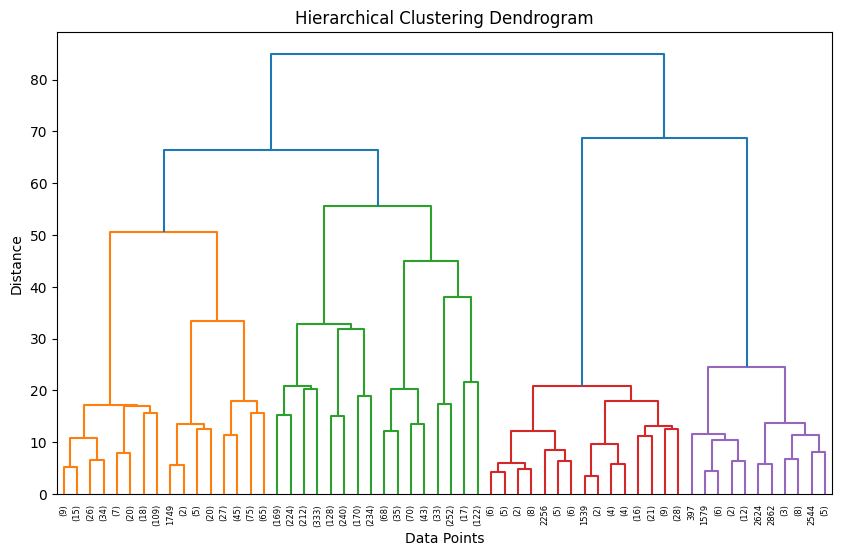

In [11]:
plt.figure(figsize=(10,6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()